<h1>Tarea 5 Análisis de Componentes Principales </h1>
    <h3 style="color:blue">Roberto Gaona Juárez</h3>

<b>1. Cargue los datos en Python y muestre los primeros 10 registros.</b>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
dataframe = pd.read_csv(r"Cars93.csv")
print(dataframe.head(10))

  Manufacturer       Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0        Acura     Integra    Small       12.9   15.9       18.8        25   
1        Acura      Legend  Midsize       29.2   33.9       38.7        18   
2         Audi          90  Compact       25.9   29.1       32.3        20   
3         Audi         100  Midsize       30.8   37.7       44.6        19   
4          BMW        535i  Midsize       23.7   30.0       36.2        22   
5        Buick     Century  Midsize       14.2   15.7       17.3        22   
6        Buick     LeSabre    Large       19.9   20.8       21.7        19   
7        Buick  Roadmaster    Large       22.6   23.7       24.9        16   
8        Buick     Riviera  Midsize       26.3   26.3       26.3        19   
9     Cadillac     DeVille    Large       33.0   34.7       36.3        16   

   MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
0           31                None      Front  ...          5     17

In [5]:
dataframe.isna().sum()/len(dataframe)*100

Manufacturer           0.000000
Model                  0.000000
Type                   0.000000
Min.Price              0.000000
Price                  0.000000
Max.Price              0.000000
MPG.city               0.000000
MPG.highway            0.000000
AirBags                0.000000
DriveTrain             0.000000
Cylinders              0.000000
EngineSize             0.000000
Horsepower             0.000000
RPM                    0.000000
Rev.per.mile           0.000000
Man.trans.avail        0.000000
Fuel.tank.capacity     0.000000
Passengers             0.000000
Length                 0.000000
Wheelbase              0.000000
Width                  0.000000
Turn.circle            0.000000
Rear.seat.room         2.150538
Luggage.room          11.827957
Weight                 0.000000
Origin                 0.000000
Make                   0.000000
dtype: float64

<b>2. Remplace los valores faltantes de las columnas numéricas por la media aritmética.</b>

In [6]:
numeric =dataframe.select_dtypes(include=np.number)
numeric_columns = numeric.columns
dataframe[numeric_columns] = dataframe[numeric_columns].fillna(dataframe.mean(numeric_only= True))
dataframe.isna().sum()/len(dataframe)*100

Manufacturer          0.0
Model                 0.0
Type                  0.0
Min.Price             0.0
Price                 0.0
Max.Price             0.0
MPG.city              0.0
MPG.highway           0.0
AirBags               0.0
DriveTrain            0.0
Cylinders             0.0
EngineSize            0.0
Horsepower            0.0
RPM                   0.0
Rev.per.mile          0.0
Man.trans.avail       0.0
Fuel.tank.capacity    0.0
Passengers            0.0
Length                0.0
Wheelbase             0.0
Width                 0.0
Turn.circle           0.0
Rear.seat.room        0.0
Luggage.room          0.0
Weight                0.0
Origin                0.0
Make                  0.0
dtype: float64

<b>3. Estandarice los valores.</b>

In [33]:
scaler=StandardScaler()
df = dataframe.drop(['Manufacturer','Model','Type','AirBags','DriveTrain','Man.trans.avail','Origin','Make','Cylinders'], axis=1)  # quito la variable dependiente "Y"
scaler.fit(df) # calculo la media para poder hacer la transformacion
X_scaled=scaler.transform(df)# Ahora si, escalo los datos y los normalizo

In [15]:
pca=PCA(n_components=18) # Otra opción es instanciar pca sólo con dimensiones nuevas hasta obtener un mínimo "explicado" ej.: pca=PCA(.85)
pca.fit(X_scaled) # obtener los componentes principales
X_pca=pca.transform(X_scaled) # convertimos nuestros datos con las nuevas dimensiones de PCA
 
print("shape of X_pca", X_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:5]))

shape of X_pca (93, 18)
[6.03191854e-01 1.43741684e-01 5.97043106e-02 5.23222837e-02
 3.13040292e-02 2.22116886e-02 2.00405747e-02 1.58527018e-02
 1.36231262e-02 1.11085781e-02 7.23150267e-03 5.54597872e-03
 4.59664570e-03 3.33810149e-03 2.94213525e-03 1.91886804e-03
 1.32566025e-03 2.76943042e-07]
suma: 0.8902641615817105


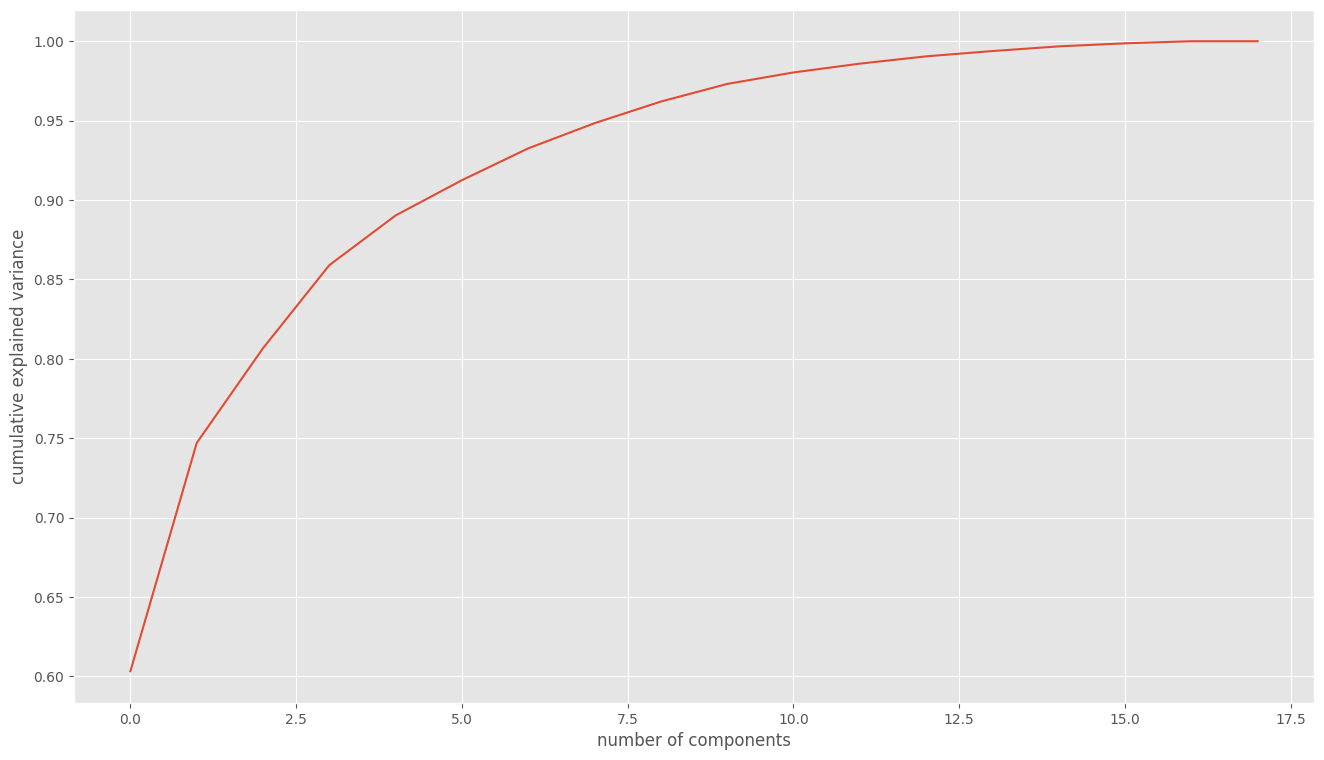

In [16]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

shape of X_pca (93, 4)
[0.60319185 0.14374168 0.05970431 0.05232228]
suma: 0.8589601323849031


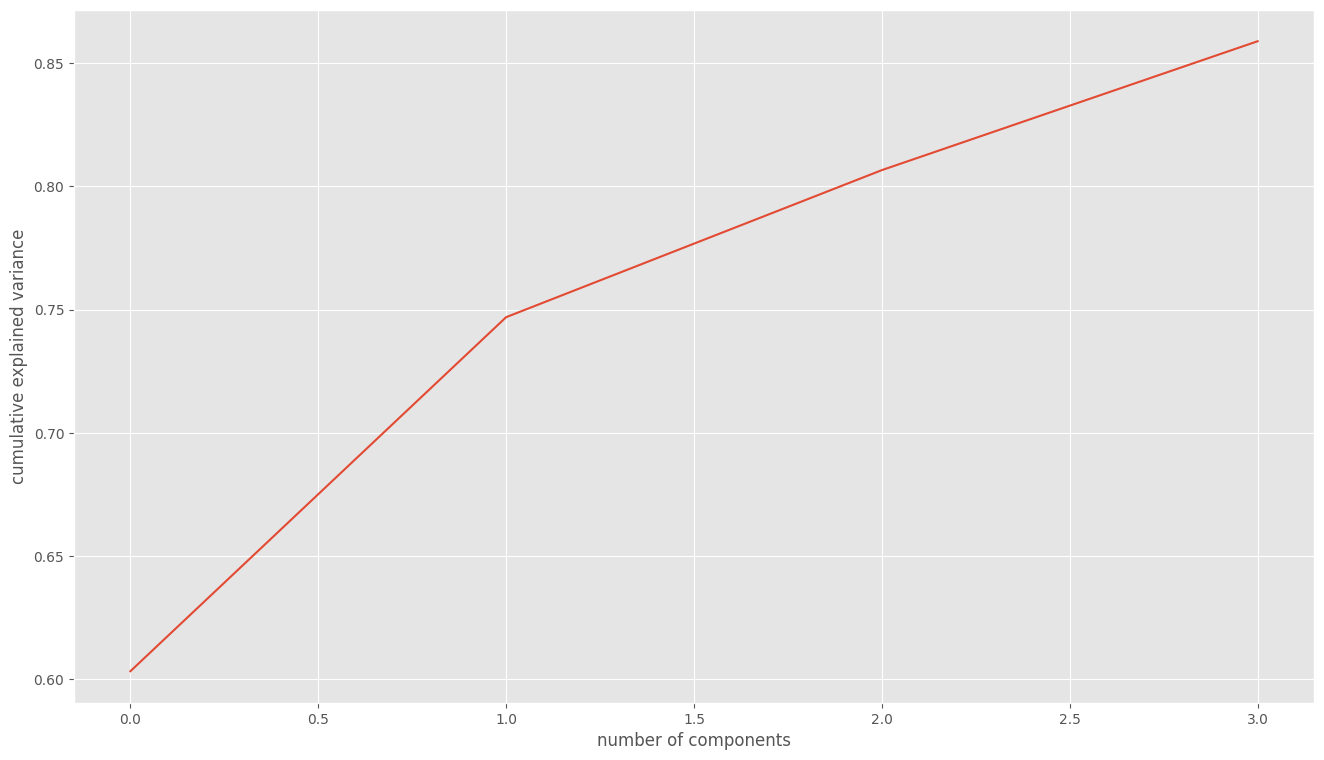

In [17]:
pca=PCA(n_components=4) # Otra opción es instanciar pca sólo con dimensiones nuevas hasta obtener un mínimo "explicado" ej.: pca=PCA(.85)
pca.fit(X_scaled) # obtener los componentes principales
X_pca=pca.transform(X_scaled) # convertimos nuestros datos con las nuevas dimensiones de PCA
 
print("shape of X_pca", X_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:5]))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

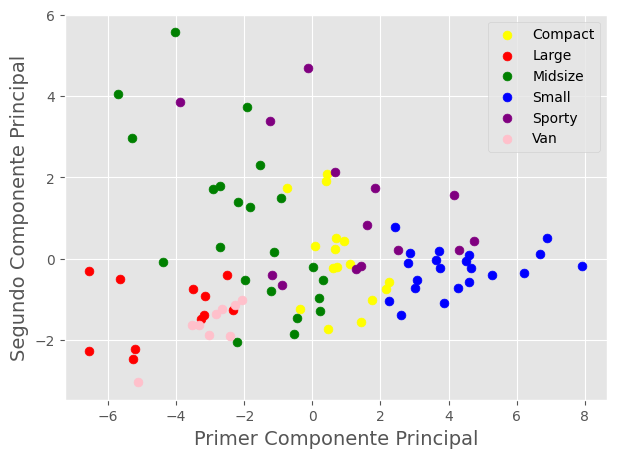

In [29]:
Xax=X_pca[:,0]
Yax=X_pca[:,1]
labels=dataframe['Type'].values
cdict={"Small":"blue","Compact":'yellow',"Midsize":'green',"Van":"pink","Large":"red","Sporty":"purple"}
labl={"Small":"Small","Compact":"Compact","Midsize":"Midsize","Van":"Van","Large":"Large","Sporty":"Sporty"}
marker={0:'*',1:'o'}
alpha={0:.3, 1:.5}
fig,ax=plt.subplots(figsize=(7,5))
fig.patch.set_facecolor('white')
for l in np.unique(labels):
    ix=np.where(labels==l)
    ax.scatter(Xax[ix],Yax[ix],c=cdict[l],label=labl[l],s=40)
plt.xlabel("Primer Componente Principal",fontsize=14)
plt.ylabel("Segundo Componente Principal",fontsize=14)
plt.legend()
plt.show()






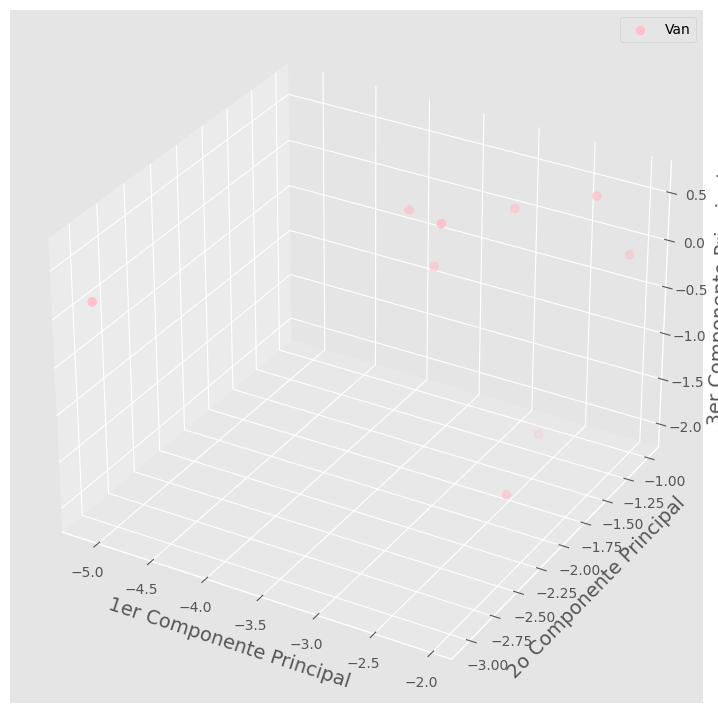

In [31]:
# Scatter

# importamos las librerias necesarias
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt

# Creamos la figura
fig = plt.figure()
# Creamos el plano 3D
ax1 = fig.add_subplot(111, projection='3d')

# Definimos los datos de prueba
x = X_pca[:,0]
y = X_pca[:,1]
z = X_pca[:,2]
labels=dataframe['Type'].values
cdict={"Small":"blue","Compact":'yellow',"Midsize":'green',"Van":"pink","Large":"red","Sporty":"purple"}
labl={"Small":"Small","Compact":"Compact","Midsize":"Midsize","Van":"Van","Large":"Large","Sporty":"Sporty"}
marker={0:'*',1:'o'}
alpha={0:.3, 1:.5}
for l in np.unique(labels):
    ix=np.where(labels==l)
ax1.scatter(x[ix], y[ix], z[ix],c=cdict[l],label=labl[l],s=40)
plt.xlabel("1er Componente Principal",fontsize=14)
plt.ylabel("2o Componente Principal",fontsize=14)
ax1.set_zlabel("3er Componente Principal",fontsize=14)
plt.legend()
plt.show()
